In [1]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import VGG16

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow: 2.21.0
GPU available: False


In [2]:
# absolute path — works regardless of where Jupyter was launched
BASE_DIR  = "/Users/manishabista/Desktop/Coursework AIML"
TRAIN_DIR = os.path.join(BASE_DIR, "Brain Tumor Classifcation", "train")
TEST_DIR  = os.path.join(BASE_DIR, "Brain Tumor Classifcation", "test")

# the folder names on disk, and the prettier labels for charts
CLASSES      = ['glioma_tumor', 'meningioma_tumor', 'normal', 'pituitary_tumor']
CLASS_LABELS = ['Glioma', 'Meningioma', 'Normal', 'Pituitary']

# 128x128 for the from-scratch models, 224x224 because VGG16 expects it
IMG_SIZE    = (128, 128)
IMG_SIZE_TL = (224, 224)

BATCH_SIZE = 32

# epoch budgets — early stopping will cut these short if validation stops improving
EPOCHS_BASELINE = 30
EPOCHS_DEEP     = 40
EPOCHS_TL       = 20

print(f"BASE_DIR    : {BASE_DIR}")
print(f"Train exists: {os.path.exists(TRAIN_DIR)}")
print(f"Test exists : {os.path.exists(TEST_DIR)}")

BASE_DIR    : /Users/manishabista/Desktop/Coursework AIML
Train exists: True
Test exists : True


In [3]:
# count images per class so we understand the dataset before touching any model
print("Dataset: Brain Tumor MRI Classification  |  Source: Kaggle")
print("=" * 60)

stats = {}
for split, path in [("Train", TRAIN_DIR), ("Test", TEST_DIR)]:
    stats[split] = {}
    for cls in CLASSES:
        cls_path = os.path.join(path, cls)
        imgs = [f for f in os.listdir(cls_path)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        stats[split][cls] = len(imgs)
    stats[split]['TOTAL'] = sum(v for k, v in stats[split].items() if k != 'TOTAL')

print(f"\n{'Class':<25} {'Train':>8} {'Test':>8} {'Total':>8}")
print("-" * 50)
for cls in CLASSES:
    total = stats['Train'][cls] + stats['Test'][cls]
    print(f"{cls:<25} {stats['Train'][cls]:>8} {stats['Test'][cls]:>8} {total:>8}")
print("-" * 50)
print(f"{'TOTAL':<25} {stats['Train']['TOTAL']:>8} {stats['Test']['TOTAL']:>8} "
      f"{stats['Train']['TOTAL'] + stats['Test']['TOTAL']:>8}")

Dataset: Brain Tumor MRI Classification  |  Source: Kaggle

Class                        Train     Test    Total
--------------------------------------------------
glioma_tumor                   713      181      894
meningioma_tumor               723      183      906
normal                         343       88      431
pituitary_tumor                668      169      837
--------------------------------------------------
TOTAL                         2447      621     3068


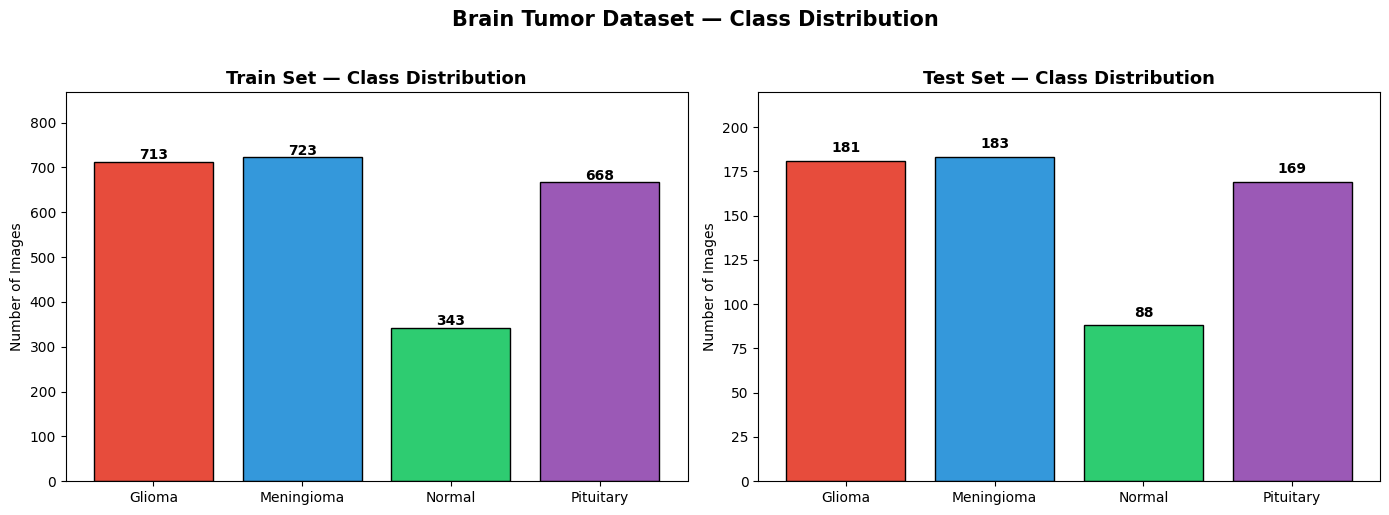

Class distribution looks balanced across all four categories.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, split in zip(axes, ["Train", "Test"]):
    counts = [stats[split][c] for c in CLASSES]
    bars = ax.bar(CLASS_LABELS, counts,
                  color=['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6'],
                  edgecolor='black')
    ax.set_title(f'{split} Set — Class Distribution', fontsize=13, fontweight='bold')
    ax.set_ylabel('Number of Images')
    ax.set_ylim(0, max(counts) * 1.2)
    for bar, val in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                str(val), ha='center', fontweight='bold')

plt.suptitle('Brain Tumor Dataset — Class Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# the four classes are reasonably balanced — no need for class weighting
print("Class distribution looks balanced across all four categories.")

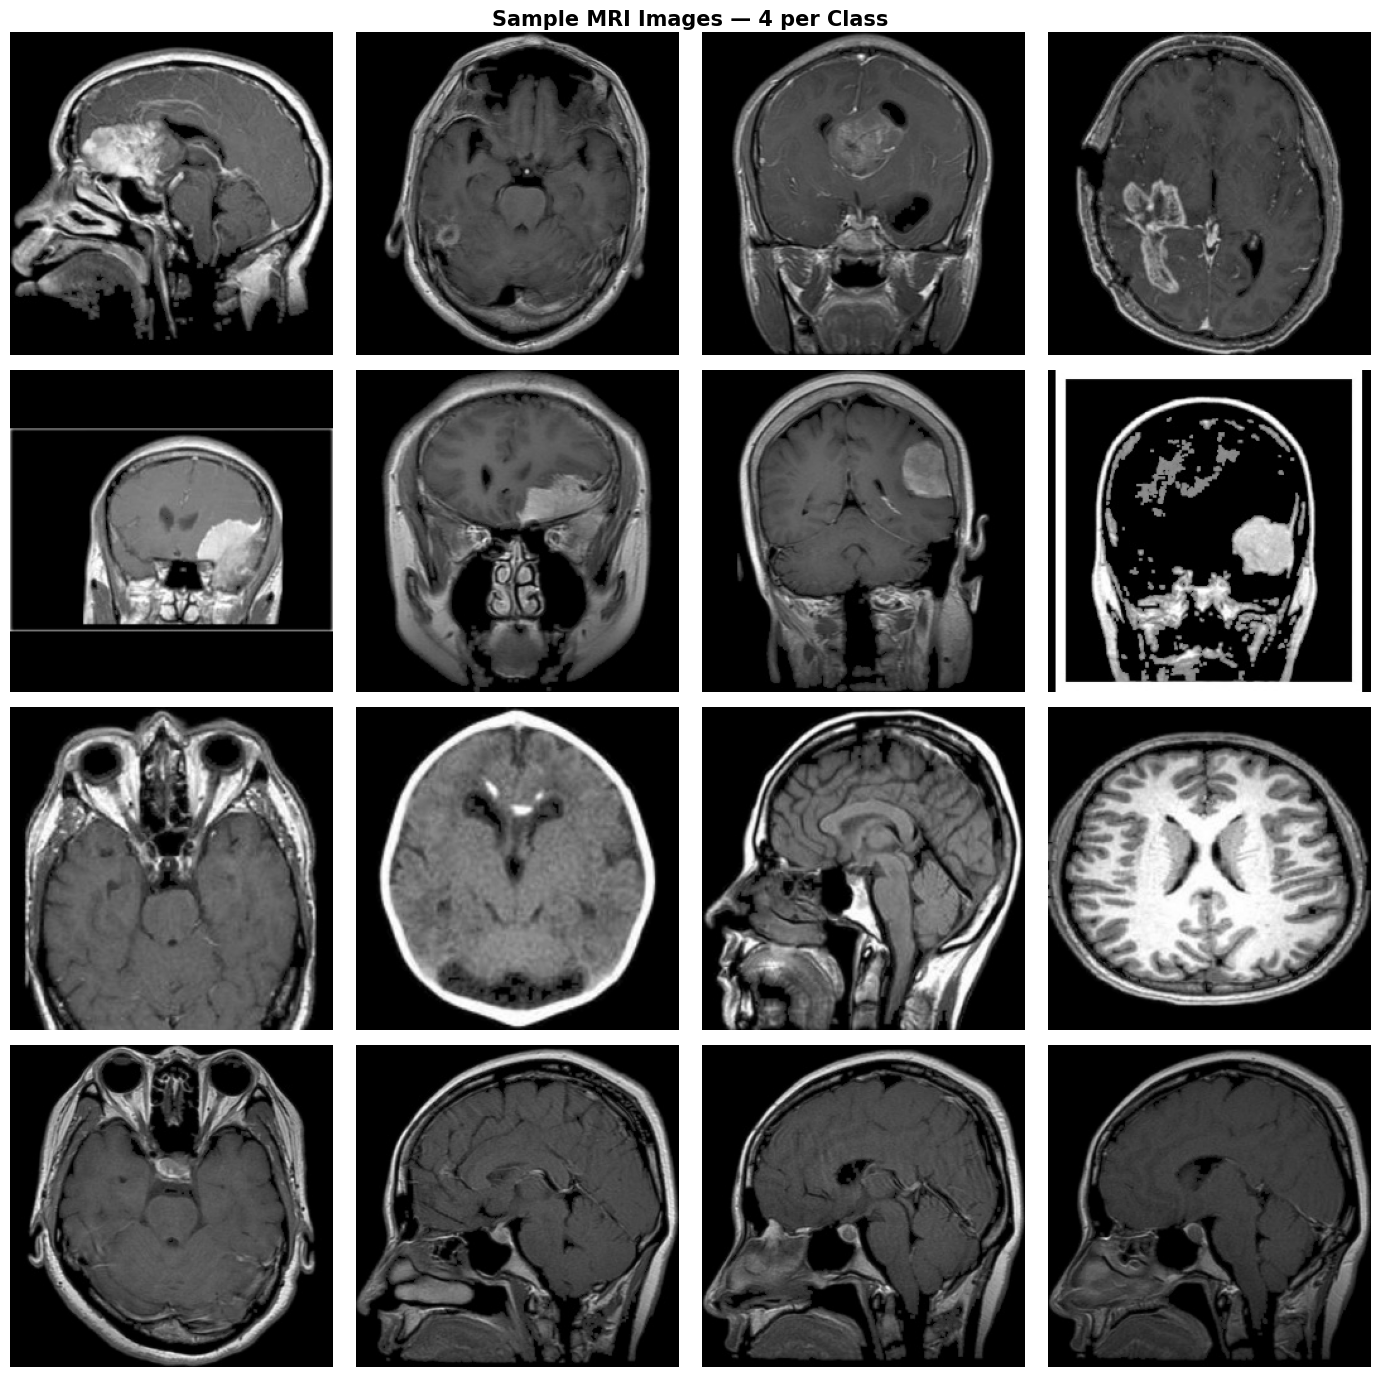

In [5]:
# show 4 examples from each class so we can visually inspect what the model will see
fig, axes = plt.subplots(4, 4, figsize=(14, 14))

for row, cls in enumerate(CLASSES):
    cls_path = os.path.join(TRAIN_DIR, cls)
    sample_files = sorted([
        f for f in os.listdir(cls_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])[:4]

    for col, img_name in enumerate(sample_files):
        img = Image.open(os.path.join(cls_path, img_name)).convert('RGB')
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_ylabel(CLASS_LABELS[row], fontsize=12,
                                       fontweight='bold', rotation=90)
            axes[row][col].yaxis.set_label_position('left')
            axes[row][col].tick_params(left=False, labelleft=False)

plt.suptitle('Sample MRI Images — 4 per Class', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# before deciding a resize target, check what sizes the raw images actually are
sizes = []
for cls in CLASSES[:2]:  # sampling two classes is enough to get the picture
    cls_path = os.path.join(TRAIN_DIR, cls)
    for f in os.listdir(cls_path)[:50]:
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            try:
                sizes.append(Image.open(os.path.join(cls_path, f)).size)
            except Exception:
                pass  # skip corrupted files

widths  = [s[0] for s in sizes]
heights = [s[1] for s in sizes]
print(f"Valid images sampled: {len(sizes)}")
print(f"Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}")
print(f"Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}")

print("\nPreprocessing decisions:")
print(f"  Resize to {IMG_SIZE} for baseline/deeper models (smaller = faster training)")
print(f"  Resize to {IMG_SIZE_TL} for VGG16 (ImageNet models expect 224x224)")
print("  Normalise pixels to [0, 1] by dividing by 255")
print("  80/20 train/validation split using ImageDataGenerator's validation_split")
print("  Augmentation on training set only — rotations, flips, zoom to reduce overfitting")

Valid images sampled: 100
Width  — min: 256, max: 256, mean: 256
Height — min: 256, max: 256, mean: 256

Preprocessing decisions:
  Resize to (128, 128) for baseline/deeper models (smaller = faster training)
  Resize to (224, 224) for VGG16 (ImageNet models expect 224x224)
  Normalise pixels to [0, 1] by dividing by 255
  80/20 train/validation split using ImageDataGenerator's validation_split
  Augmentation on training set only — rotations, flips, zoom to reduce overfitting


In [7]:
# the training generator applies augmentation; the test generator just normalises
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    validation_split=0.2   # 20% of training images go to validation
)
test_datagen = ImageDataGenerator(rescale=1.0 / 255)

def make_generators(img_size, batch_size=BATCH_SIZE):
    train_gen = train_datagen.flow_from_directory(
        TRAIN_DIR, target_size=img_size, batch_size=batch_size,
        class_mode='categorical', subset='training', seed=42, shuffle=True)
    val_gen = train_datagen.flow_from_directory(
        TRAIN_DIR, target_size=img_size, batch_size=batch_size,
        class_mode='categorical', subset='validation', seed=42, shuffle=False)
    test_gen = test_datagen.flow_from_directory(
        TEST_DIR, target_size=img_size, batch_size=batch_size,
        class_mode='categorical', shuffle=False)
    return train_gen, val_gen, test_gen

# build the default generators at 128x128 for the from-scratch models
train_gen, val_gen, test_gen = make_generators(IMG_SIZE)
print(f"Train batches: {len(train_gen)}  |  Val batches: {len(val_gen)}  |  Test batches: {len(test_gen)}")
print(f"Class mapping: {train_gen.class_indices}")

Found 1960 images belonging to 4 classes.
Found 487 images belonging to 4 classes.
Found 621 images belonging to 4 classes.
Train batches: 62  |  Val batches: 16  |  Test batches: 20
Class mapping: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'normal': 2, 'pituitary_tumor': 3}


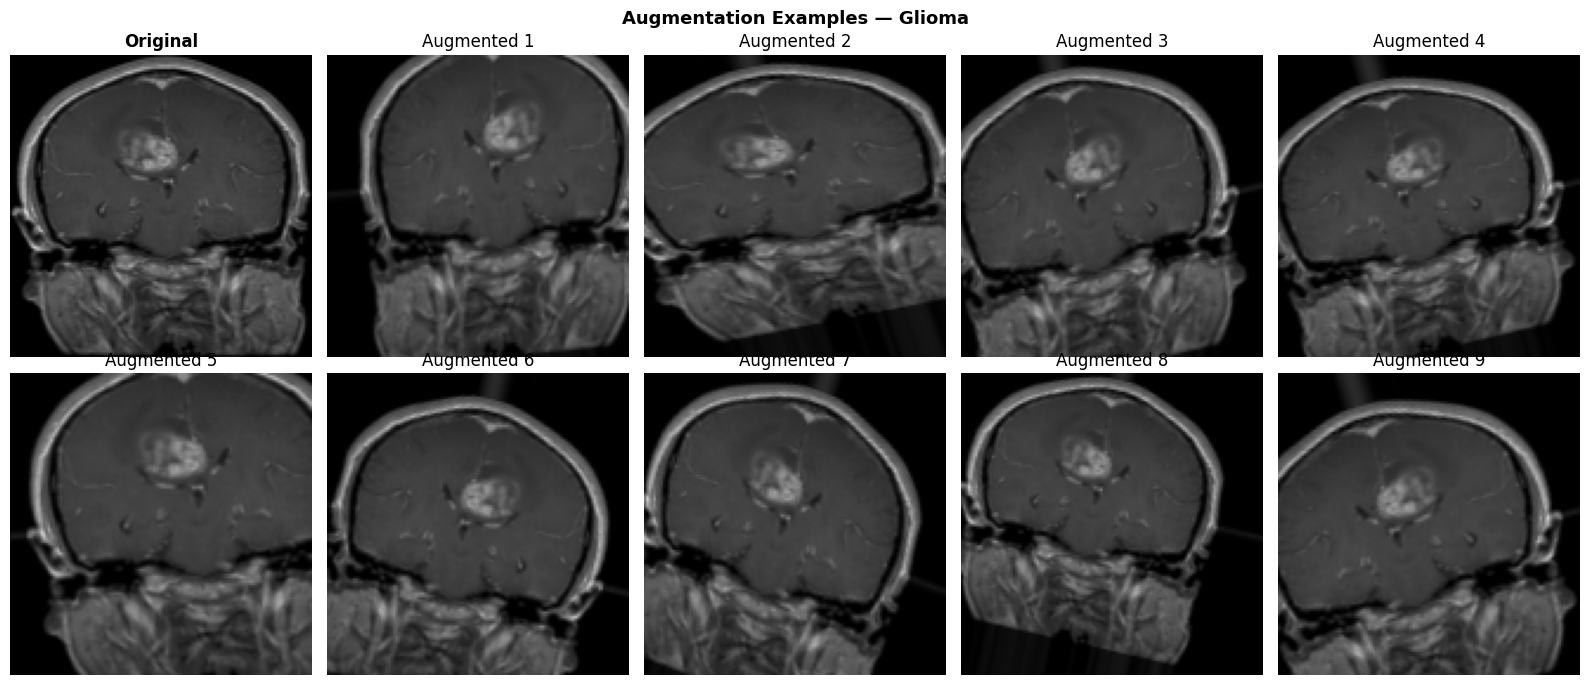

In [8]:
# show what the training augmentation actually does to a single image
# no rescale here — the image is already divided by 255 when loaded manually below
aug_datagen = ImageDataGenerator(
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1
)

sample_cls  = CLASSES[0]
sample_dir  = os.path.join(TRAIN_DIR, sample_cls)
sample_file = [f for f in os.listdir(sample_dir) if f.lower().endswith('.jpg')][0]
sample_img  = np.expand_dims(
    np.array(Image.open(os.path.join(sample_dir, sample_file))
             .resize(IMG_SIZE).convert('RGB')) / 255.0, 0)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes[0][0].imshow(sample_img[0])
axes[0][0].set_title('Original', fontweight='bold')
axes[0][0].axis('off')

aug_iter = aug_datagen.flow(sample_img, batch_size=1)
for i in range(1, 10):
    axes[i // 5][i % 5].imshow(next(aug_iter)[0])
    axes[i // 5][i % 5].set_title(f'Augmented {i}')
    axes[i // 5][i % 5].axis('off')

plt.suptitle(f'Augmentation Examples — {CLASS_LABELS[0]}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('augmentation_samples.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# three conv+pool blocks exactly as the spec requires, followed by three dense layers
# filters double each block (32 -> 64 -> 128) — a standard progression for feature learning
def build_baseline_cnn(input_shape=(128, 128, 3), num_classes=4):
    model = models.Sequential([
        # first block: 32 filters — picks up edges and basic textures
        layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                      input_shape=input_shape, name='conv1'),
        layers.MaxPooling2D((2, 2), name='pool1'),

        # second block: 64 filters — starts combining textures into shapes
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2'),
        layers.MaxPooling2D((2, 2), name='pool2'),

        # third block: 128 filters — learns higher-level patterns like tumour edges
        layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3'),
        layers.MaxPooling2D((2, 2), name='pool3'),

        # flatten and pass through three dense layers before the final softmax
        layers.Flatten(name='flatten'),
        layers.Dense(256, activation='relu', name='fc1'),
        layers.Dense(128, activation='relu', name='fc2'),
        layers.Dense(64,  activation='relu', name='fc3'),
        layers.Dense(num_classes, activation='softmax', name='output'),
    ], name='Baseline_CNN')
    return model

baseline_model = build_baseline_cnn()
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc3 (Dense)                     │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,523,524 (32.51 MB)

 Trainable params: 8,523,524 (32.51 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# stop early if validation loss plateaus to avoid overfitting
callbacks_baseline = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1),
]

start = time.time()
history_baseline = baseline_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_BASELINE,
    callbacks=callbacks_baseline,
    verbose=1,
)
baseline_train_time = time.time() - start
print(f"\nBaseline training finished in {baseline_train_time:.1f}s")
# note: if this is too slow, switch to Google Colab with GPU/TPU enabled

Epoch 1/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 145ms/step - accuracy: 0.3260 - loss: 1.3445 - val_accuracy: 0.2423 - val_loss: 1.3487 - learning_rate: 0.0010
Epoch 2/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 139ms/step - accuracy: 0.4408 - loss: 1.2201 - val_accuracy: 0.5462 - val_loss: 1.0895 - learning_rate: 0.0010
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 143ms/step - accuracy: 0.5485 - loss: 1.0280 - val_accuracy: 0.4969 - val_loss: 1.0283 - learning_rate: 0.0010
Epoch 4/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 144ms/step - accuracy: 0.5852 - loss: 0.9698 - val_accuracy: 0.6078 - val_loss: 0.9051 - learning_rate: 0.0010
Epoch 5/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 145ms/step - accuracy: 0.6077 - loss: 0.8919 - val_accuracy: 0.6838 - val_loss: 0.7742 - learning_rate: 0.0010
Epoch 6/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 147ms/step - accuracy: 0.6546 - loss: 0.8280 - val_accuracy: 0.6181 - val_loss: 0.8990 - learning_rate: 0.0010
Epoch 7/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 149ms/step - accuracy: 0.6730 - loss: 0.7827 -

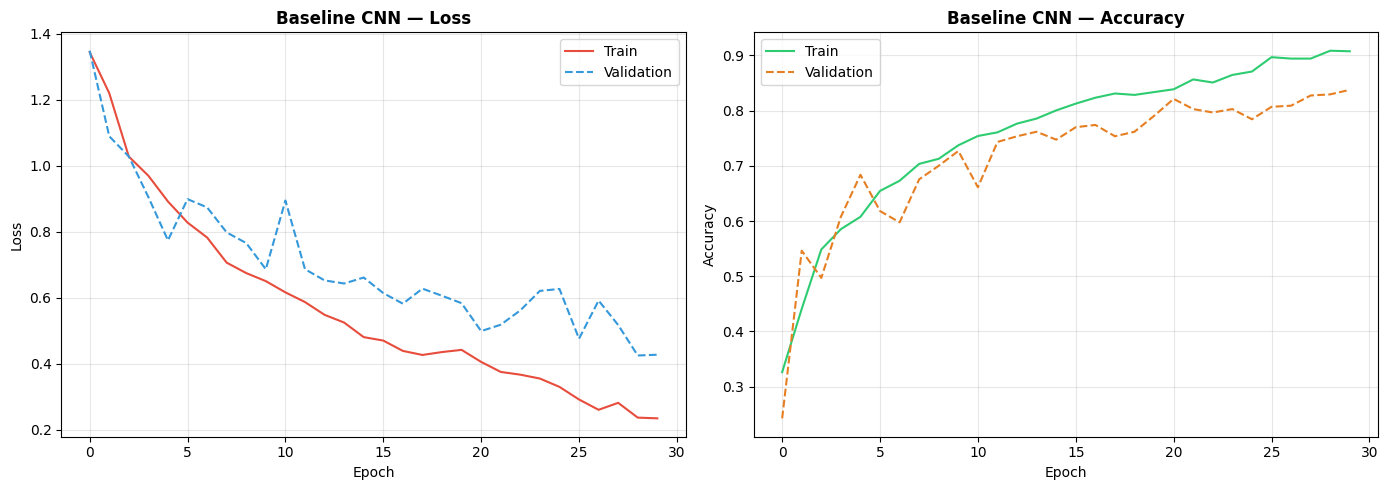

In [11]:
# reusable function — every model will use this to plot its loss and accuracy curves
def plot_history(history, title, save_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['loss'],     label='Train',      color='#E74C3C')
    axes[0].plot(history.history['val_loss'], label='Validation', color='#3498DB', linestyle='--')
    axes[0].set_title(f'{title} — Loss', fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(history.history['accuracy'],     label='Train',      color='#2ECC71')
    axes[1].plot(history.history['val_accuracy'], label='Validation', color='#E67E22', linestyle='--')
    axes[1].set_title(f'{title} — Accuracy', fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()

plot_history(history_baseline, 'Baseline CNN', 'baseline_training_curves.png')


Baseline CNN — Test Results
Accuracy: 0.8229  (82.29%)

Classification Report (precision, recall, F1 per class):
              precision    recall  f1-score   support

      Glioma       0.84      0.83      0.84       181
  Meningioma       0.81      0.71      0.76       183
      Normal       0.85      0.73      0.79        88
   Pituitary       0.80      0.98      0.88       169

    accuracy                           0.82       621
   macro avg       0.83      0.81      0.82       621
weighted avg       0.82      0.82      0.82       621



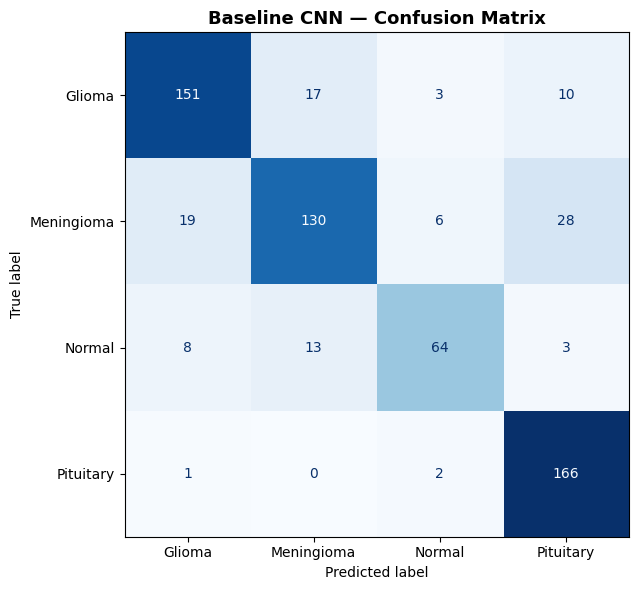

In [12]:
# reusable evaluation function — prints accuracy, full classification report, and confusion matrix
def evaluate_model(model, test_generator, model_name="Model"):
    test_generator.reset()
    y_pred_probs = model.predict(test_generator, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = test_generator.classes

    acc = accuracy_score(y_true, y_pred)
    print(f"\n{model_name} — Test Results")
    print("=" * 55)
    print(f"Accuracy: {acc:.4f}  ({acc * 100:.2f}%)")
    print("\nClassification Report (precision, recall, F1 per class):")
    print(classification_report(y_true, y_pred, target_names=CLASS_LABELS))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LABELS).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{model_name} — Confusion Matrix', fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{model_name.replace(" ", "_")}_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    return acc, y_pred, y_true

baseline_acc, baseline_preds, y_true = evaluate_model(baseline_model, test_gen, "Baseline CNN")

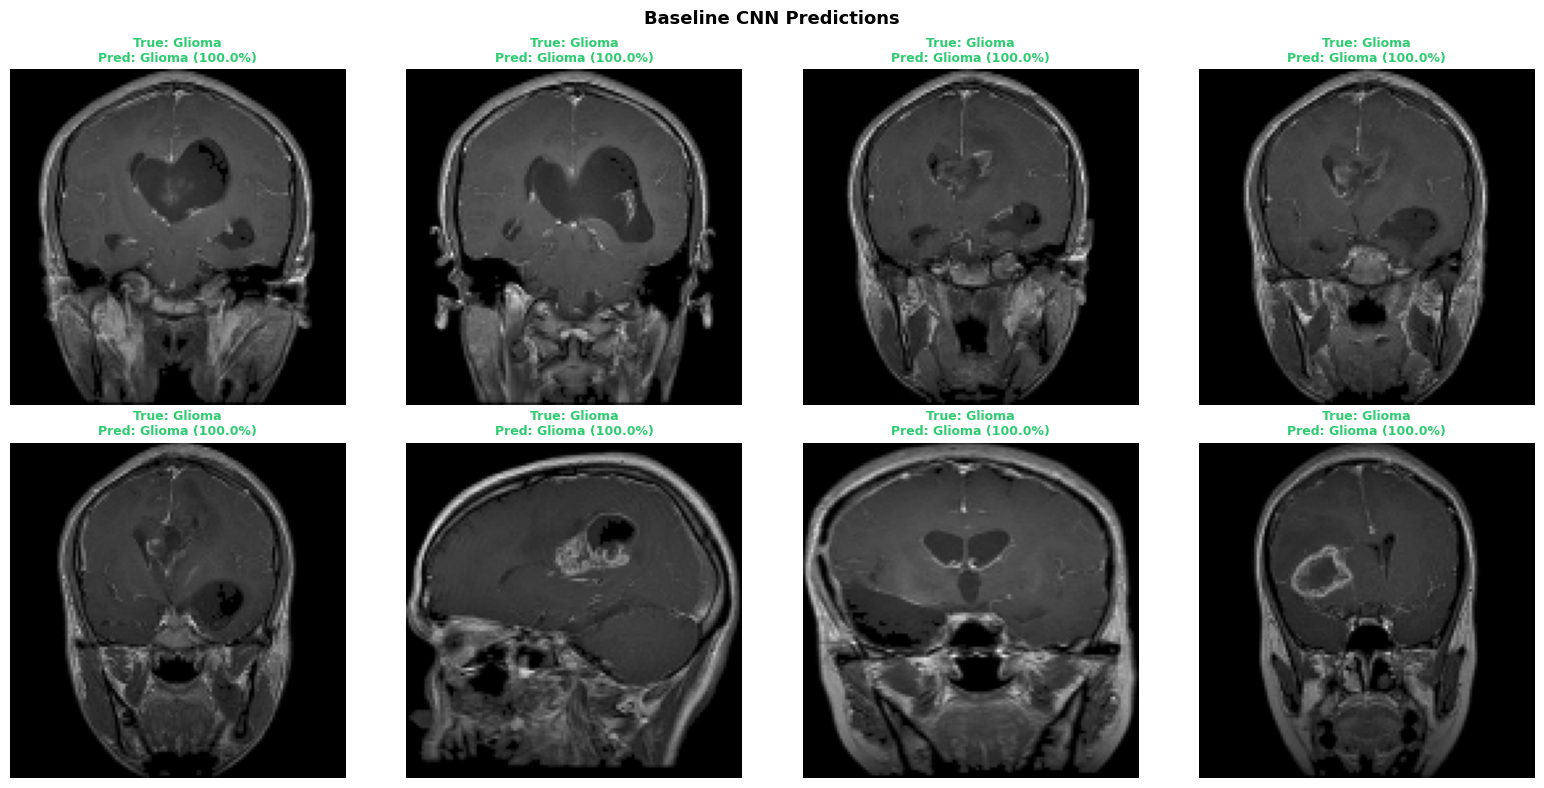

In [13]:
# pick a random batch and show what the model actually predicts
# green title = correct, red = wrong — makes misclassifications easy to spot
def show_predictions(model, test_generator, num_samples=8, title="Predictions"):
    test_generator.reset()
    imgs, labels = next(test_generator)
    preds = model.predict(imgs, verbose=0)

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for i, ax in enumerate(axes.flat):
        if i >= num_samples:
            break
        ax.imshow(imgs[i])
        true_cls = CLASS_LABELS[np.argmax(labels[i])]
        pred_cls = CLASS_LABELS[np.argmax(preds[i])]
        conf     = np.max(preds[i]) * 100
        color    = '#2ECC71' if true_cls == pred_cls else '#E74C3C'
        ax.set_title(f'True: {true_cls}\nPred: {pred_cls} ({conf:.1f}%)',
                     fontsize=9, color=color, fontweight='bold')
        ax.axis('off')

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

show_predictions(baseline_model, test_gen, title="Baseline CNN Predictions")

In [14]:
# deeper version: 4 blocks instead of 3, each block has two conv layers
# BatchNorm keeps activations stable during training; Dropout prevents co-adaptation
def build_deeper_cnn(input_shape=(128, 128, 3), num_classes=4):
    model = models.Sequential([
        # block 1 — two conv layers at 32 filters before pooling
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # block 2 — stepping up to 64 filters
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # block 3 — 128 filters, learning complex shapes
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # block 4 — extra depth vs baseline, 256 filters for fine-grained features
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # bigger dense head to match the deeper feature extractor
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),  # reduced from 0.5 — heavy dropout was hurting convergence
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax'),
    ], name='Deeper_CNN')
    return model

deeper_model_adam = build_deeper_cnn()
deeper_model_adam.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),  # lowered: 1e-3 was too high for this deep BN model
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
deeper_model_adam.summary()
print(f"\nBaseline parameters : {baseline_model.count_params():,}")
print(f"Deeper parameters   : {deeper_model_adam.count_params():,}")

Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,04

 Total params: 9,697,700 (36.99 MB)

 Trainable params: 9,695,716 (36.99 MB)

 Non-trainable params: 1,984 (7.75 KB)


Baseline parameters : 8,523,524
Deeper parameters   : 9,697,700


Epoch 1/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 52s 800ms/step - accuracy: 0.4434 - loss: 1.4253 - val_accuracy: 0.2916 - val_loss: 1.8646 - learning_rate: 3.0000e-04
Epoch 2/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.5413 - loss: 1.1632 - val_accuracy: 0.2731 - val_loss: 3.0606 - learning_rate: 3.0000e-04
Epoch 3/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 58s 937ms/step - accuracy: 0.5883 - loss: 1.0572 - val_accuracy: 0.1376 - val_loss: 5.8640 - learning_rate: 3.0000e-04
Epoch 4/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 56s 905ms/step - accuracy: 0.6296 - loss: 0.9167 - val_accuracy: 0.2731 - val_loss: 9.3748 - learning_rate: 3.0000e-04
Epoch 5/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 51s 816ms/step - accuracy: 0.6592 - loss: 0.8560 - val_accuracy: 0.3080 - val_loss: 6.9165 - learning_rate: 3.0000e-04
Epoch 6/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 793ms/step - accuracy: 0.6757 - loss: 0.8000
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
62/62 ━━━━━━━━━━━━━━━━━━━━ 52s 843ms/step - accuracy: 0.

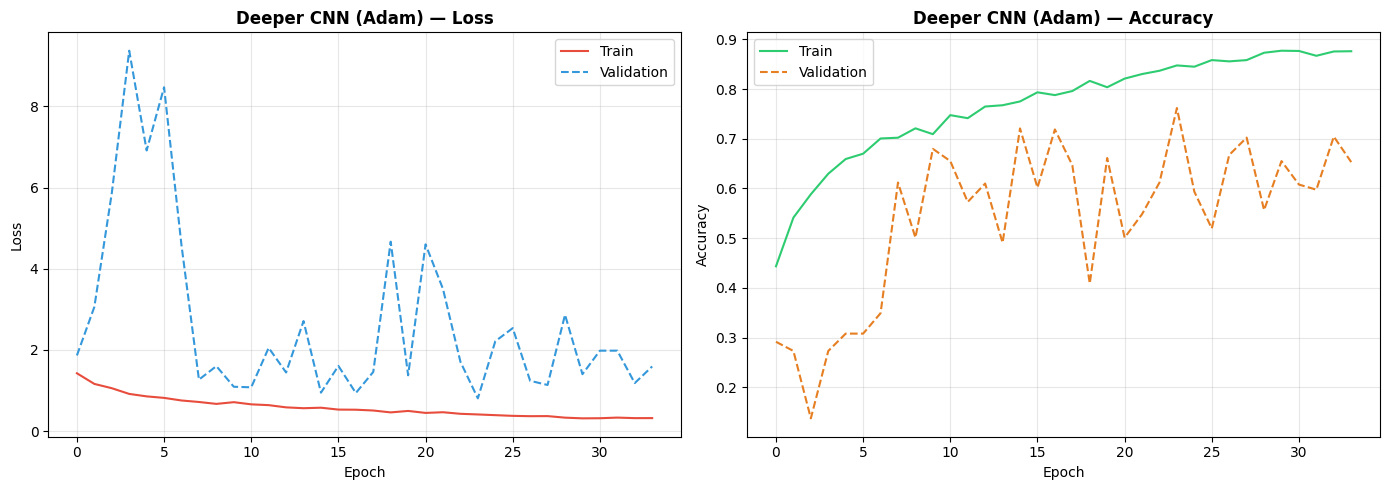


Deeper CNN Adam — Test Results
Accuracy: 0.6602  (66.02%)

Classification Report (precision, recall, F1 per class):
              precision    recall  f1-score   support

      Glioma       0.82      0.78      0.80       181
  Meningioma       0.90      0.31      0.46       183
      Normal       0.88      0.50      0.64        88
   Pituitary       0.50      1.00      0.67       169

    accuracy                           0.66       621
   macro avg       0.78      0.65      0.64       621
weighted avg       0.77      0.66      0.64       621



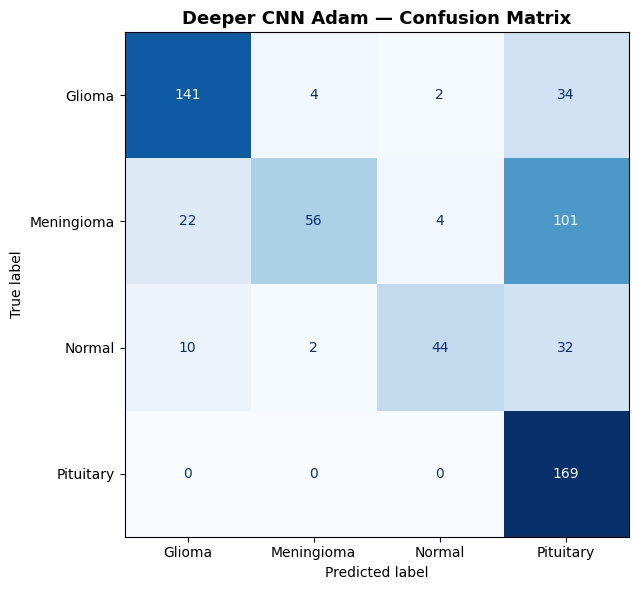

In [15]:
callbacks_deep = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
]

start = time.time()
history_deeper_adam = deeper_model_adam.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS_DEEP, callbacks=callbacks_deep, verbose=1,
)
deeper_adam_time = time.time() - start
print(f"Deeper CNN (Adam) finished in {deeper_adam_time:.1f}s")

plot_history(history_deeper_adam, 'Deeper CNN (Adam)', 'deeper_adam_training_curves.png')
deeper_adam_acc, _, _ = evaluate_model(deeper_model_adam, test_gen, "Deeper CNN Adam")

Epoch 1/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 53s 825ms/step - accuracy: 0.3969 - loss: 1.5719 - val_accuracy: 0.3922 - val_loss: 1.2256 - learning_rate: 0.0010
Epoch 2/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 51s 819ms/step - accuracy: 0.4888 - loss: 1.2904 - val_accuracy: 0.2977 - val_loss: 2.1199 - learning_rate: 0.0010
Epoch 3/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 50s 814ms/step - accuracy: 0.5306 - loss: 1.1541 - val_accuracy: 0.3388 - val_loss: 1.8044 - learning_rate: 0.0010
Epoch 4/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 51s 820ms/step - accuracy: 0.5423 - loss: 1.0602 - val_accuracy: 0.3285 - val_loss: 2.6035 - learning_rate: 0.0010
Epoch 5/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 49s 798ms/step - accuracy: 0.5648 - loss: 1.0367 - val_accuracy: 0.3737 - val_loss: 2.1517 - learning_rate: 0.0010
Epoch 6/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 769ms/step - accuracy: 0.5895 - loss: 0.9699
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
62/62 ━━━━━━━━━━━━━━━━━━━━ 51s 826ms/step - accuracy: 0.6036 - loss: 0.95

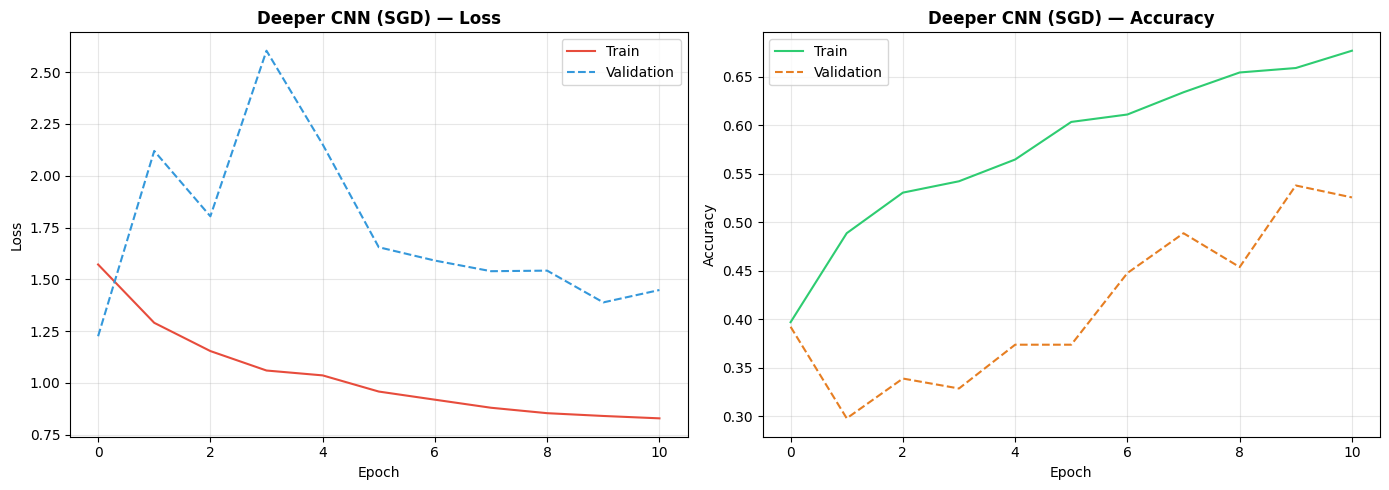


Deeper CNN SGD — Test Results
Accuracy: 0.3865  (38.65%)

Classification Report (precision, recall, F1 per class):
              precision    recall  f1-score   support

      Glioma       0.37      0.06      0.10       181
  Meningioma       0.64      0.13      0.21       183
      Normal       0.51      0.48      0.49        88
   Pituitary       0.35      0.97      0.51       169

    accuracy                           0.39       621
   macro avg       0.47      0.41      0.33       621
weighted avg       0.46      0.39      0.30       621



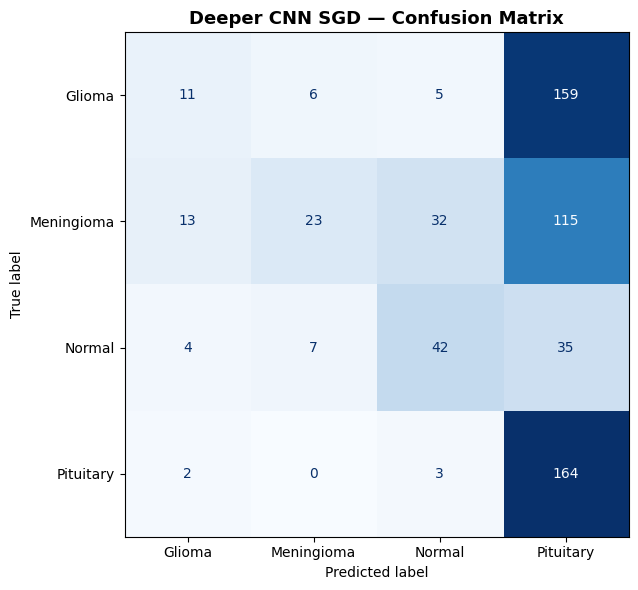

In [16]:
# same architecture, different optimiser — lets us compare Adam vs SGD convergence
deeper_model_sgd = build_deeper_cnn()
deeper_model_sgd.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.001, momentum=0.9, nesterov=True),  # BUG FIX: 0.01 caused val_loss explosion (79.0 in epoch 1)
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start = time.time()
# fresh callbacks — avoids reusing the stale state from Adam training
callbacks_sgd = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
]
history_deeper_sgd = deeper_model_sgd.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS_DEEP, callbacks=callbacks_sgd, verbose=1,
)
deeper_sgd_time = time.time() - start
print(f"Deeper CNN (SGD) finished in {deeper_sgd_time:.1f}s")

plot_history(history_deeper_sgd, 'Deeper CNN (SGD)', 'deeper_sgd_training_curves.png')
deeper_sgd_acc, _, _ = evaluate_model(deeper_model_sgd, test_gen, "Deeper CNN SGD")

Epoch 1/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 45s 711ms/step - accuracy: 0.2816 - loss: 1.3684 - val_accuracy: 0.2916 - val_loss: 1.3510 - learning_rate: 3.0000e-04
Epoch 2/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 40s 649ms/step - accuracy: 0.2755 - loss: 1.3622 - val_accuracy: 0.2916 - val_loss: 1.3502 - learning_rate: 3.0000e-04
Epoch 3/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 40s 643ms/step - accuracy: 0.2954 - loss: 1.3506 - val_accuracy: 0.2916 - val_loss: 1.3528 - learning_rate: 3.0000e-04
Epoch 4/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 39s 635ms/step - accuracy: 0.3490 - loss: 1.3074 - val_accuracy: 0.4148 - val_loss: 1.2700 - learning_rate: 3.0000e-04
Epoch 5/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 39s 632ms/step - accuracy: 0.3337 - loss: 1.3051 - val_accuracy: 0.4086 - val_loss: 1.2141 - learning_rate: 3.0000e-04
Epoch 6/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 42s 678ms/step - accuracy: 0.3770 - loss: 1.2648 - val_accuracy: 0.4025 - val_loss: 1.1816 - learning_rate: 3.0000e-04
Epoch 7/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 44s 714ms/step - acc

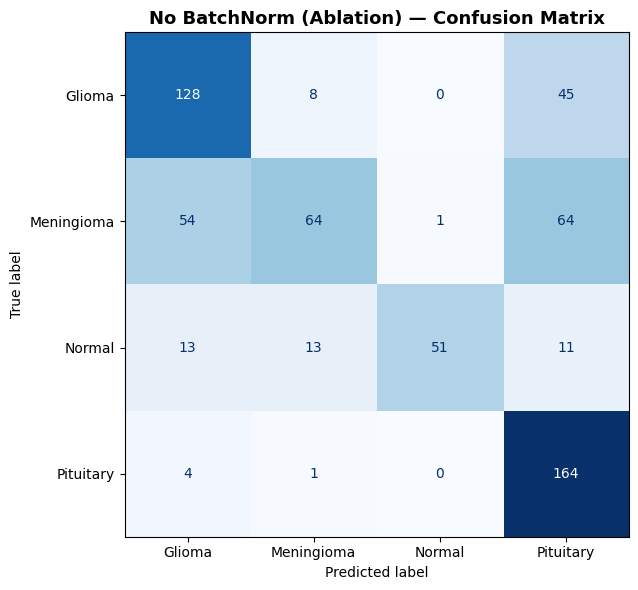


With BatchNorm: 66.02%  |  Without: 65.54%


In [17]:
# ablation: take out BatchNormalization to see how much it actually helps
def build_deeper_no_bn(input_shape=(128, 128, 3), num_classes=4):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax'),
    ], name='Deeper_No_BN')
    return model

ablation_model = build_deeper_no_bn()
ablation_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),  # explicit lr to match deeper model
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# fresh callbacks — BUG FIX: reusing callbacks_deep caused stale best_weights and early stopping misfiring
callbacks_ablation = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
]
history_ablation = ablation_model.fit(
    train_gen, validation_data=val_gen,
    epochs=40, callbacks=callbacks_ablation, verbose=1,  # BUG FIX: epochs 20->40; NoBN needs more time without BN stabilisation
)
ablation_acc, _, _ = evaluate_model(ablation_model, test_gen, "No BatchNorm (Ablation)")
print(f"\nWith BatchNorm: {deeper_adam_acc*100:.2f}%  |  Without: {ablation_acc*100:.2f}%")

            Model  Parameters Accuracy % Train Time (s)
     Baseline CNN     8523524     82.29%            329
Deeper CNN (Adam)     9697700     66.02%           1728
 Deeper CNN (SGD)     9697700     38.65%            572
     No BatchNorm     9693732     65.54%            N/A


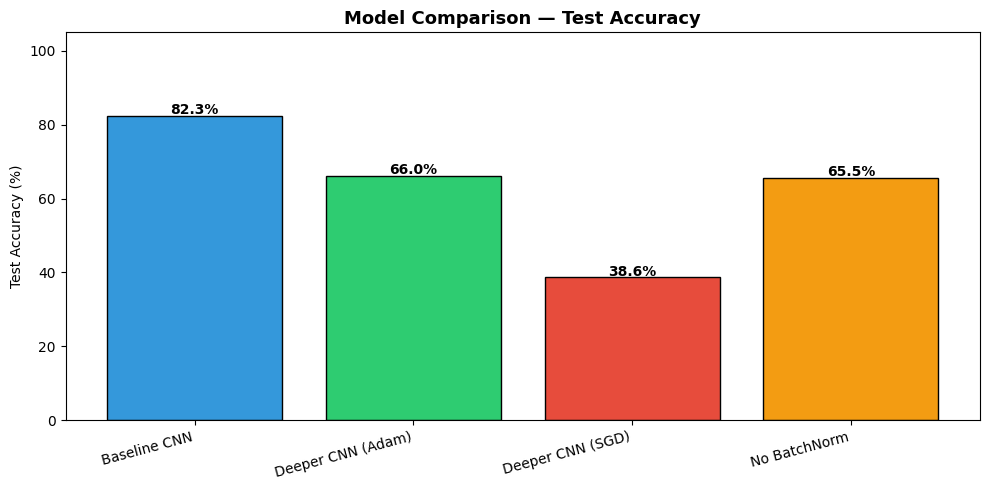

In [18]:
# pull everything together into one comparison table
summary = {
    'Model'          : ['Baseline CNN', 'Deeper CNN (Adam)', 'Deeper CNN (SGD)', 'No BatchNorm'],
    'Parameters'     : [baseline_model.count_params(), deeper_model_adam.count_params(),
                        deeper_model_sgd.count_params(), ablation_model.count_params()],
    'Test Accuracy'  : [baseline_acc, deeper_adam_acc, deeper_sgd_acc, ablation_acc],
    'Train Time (s)' : [f"{baseline_train_time:.0f}", f"{deeper_adam_time:.0f}",
                        f"{deeper_sgd_time:.0f}", "N/A"],
}

df_summary = pd.DataFrame(summary)
df_summary['Accuracy %'] = df_summary['Test Accuracy'].apply(lambda x: f"{x*100:.2f}%")
print(df_summary[['Model', 'Parameters', 'Accuracy %', 'Train Time (s)']].to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
accs = [a * 100 for a in summary['Test Accuracy']]
bars = ax.bar(summary['Model'], accs,
              color=['#3498DB', '#2ECC71', '#E74C3C', '#F39C12'],
              edgecolor='black')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Model Comparison — Test Accuracy', fontsize=13, fontweight='bold')
ax.set_ylim(0, 105)
for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# VGG16 was trained on ImageNet — its convolutional layers already know how to detect
# edges, textures, and shapes. We just swap the 1000-class head for our 4-class one.

# need new generators at 224x224 because VGG16 expects that input size
train_gen_tl, val_gen_tl, test_gen_tl = make_generators(IMG_SIZE_TL)

# load the convolutional base, exclude the original top (we'll add our own)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # keep VGG16 frozen for Phase 1

tl_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(4, activation='softmax'),
], name='VGG16_Transfer_Learning')

tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
tl_model.summary()
print(f"\nTrainable layers in Phase 1: {sum(1 for l in tl_model.layers if l.trainable)}")

Found 1960 images belonging to 4 classes.
Found 487 images belonging to 4 classes.
Found 621 images belonging to 4 classes.


Model: "VGG16_Transfer_Learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,880,452 (56.76 MB)

 Trainable params: 165,252 (645.52 KB)

 Non-trainable params: 14,715,200 (56.13 MB)


Trainable layers in Phase 1: 7


Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 211s 3s/step - accuracy: 0.5434 - loss: 1.1683 - val_accuracy: 0.5688 - val_loss: 1.1355 - learning_rate: 0.0010
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 238s 4s/step - accuracy: 0.6628 - loss: 0.8492 - val_accuracy: 0.6591 - val_loss: 1.0058 - learning_rate: 0.0010
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 203s 3s/step - accuracy: 0.7010 - loss: 0.7576 - val_accuracy: 0.7043 - val_loss: 0.9562 - learning_rate: 0.0010
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 206s 3s/step - accuracy: 0.7270 - loss: 0.6982 - val_accuracy: 0.6961 - val_loss: 0.8857 - learning_rate: 0.0010
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 232s 4s/step - accuracy: 0.7459 - loss: 0.6493 - val_accuracy: 0.7166 - val_loss: 0.7598 - learning_rate: 0.0010
Epoch 6/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 245s 4s/step - accuracy: 0.7480 - loss: 0.6294 - val_accuracy: 0.7536 - val_loss: 0.6248 - learning_rate: 0.0010
Epoch 7/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 255s 4s/step - accuracy: 0.7602 - loss: 0.5979 - val_acc

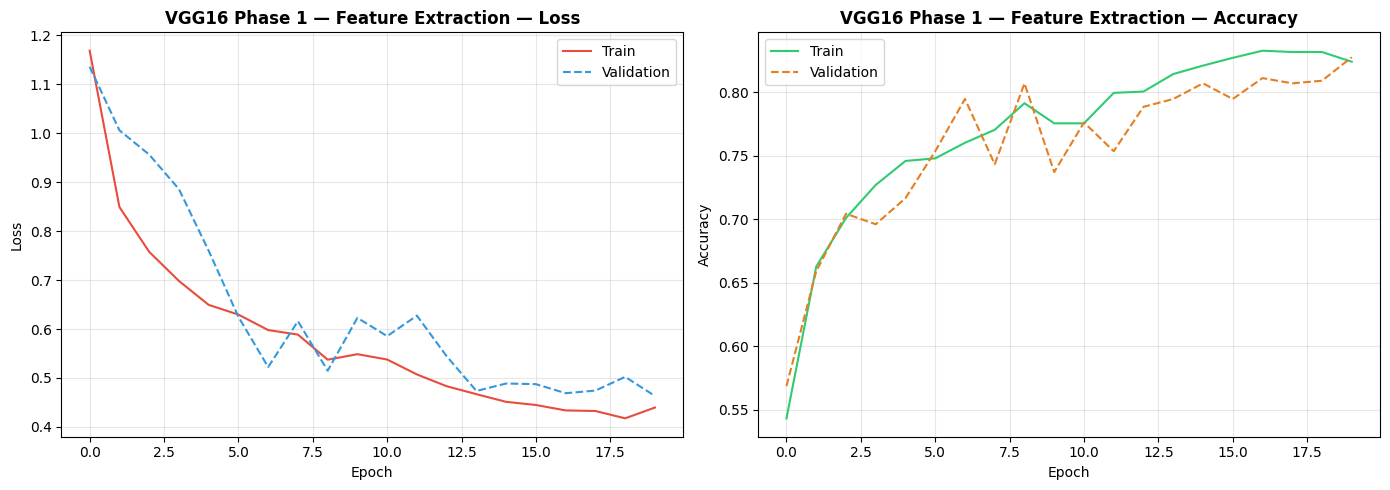

In [20]:
# Phase 1: VGG16 base is frozen — we only update the dense layers we added
callbacks_tl = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=4, min_lr=1e-7, verbose=1),
]

start = time.time()
history_tl_p1 = tl_model.fit(
    train_gen_tl, validation_data=val_gen_tl,
    epochs=EPOCHS_TL, callbacks=callbacks_tl, verbose=1,
)
tl_p1_time = time.time() - start
print(f"Phase 1 done in {tl_p1_time:.1f}s")
plot_history(history_tl_p1, 'VGG16 Phase 1 — Feature Extraction', 'tl_phase1_curves.png')

Layers now trainable: 4
Epoch 1/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 247s 4s/step - accuracy: 0.8316 - loss: 0.4263 - val_accuracy: 0.8255 - val_loss: 0.4579 - learning_rate: 1.0000e-05
Epoch 2/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 259s 4s/step - accuracy: 0.8684 - loss: 0.3598 - val_accuracy: 0.8275 - val_loss: 0.4334 - learning_rate: 1.0000e-05
Epoch 3/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 243s 4s/step - accuracy: 0.8791 - loss: 0.3403 - val_accuracy: 0.8296 - val_loss: 0.3988 - learning_rate: 1.0000e-05
Epoch 4/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 248s 4s/step - accuracy: 0.8821 - loss: 0.3086 - val_accuracy: 0.8398 - val_loss: 0.4258 - learning_rate: 1.0000e-05
Epoch 5/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 247s 4s/step - accuracy: 0.9020 - loss: 0.2798 - val_accuracy: 0.8624 - val_loss: 0.3672 - learning_rate: 1.0000e-05
Epoch 6/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 247s 4s/step - accuracy: 0.9010 - loss: 0.2774 - val_accuracy: 0.8522 - val_loss: 0.4232 - learning_rate: 1.0000e-05
Epoch 7/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 246s 4s/

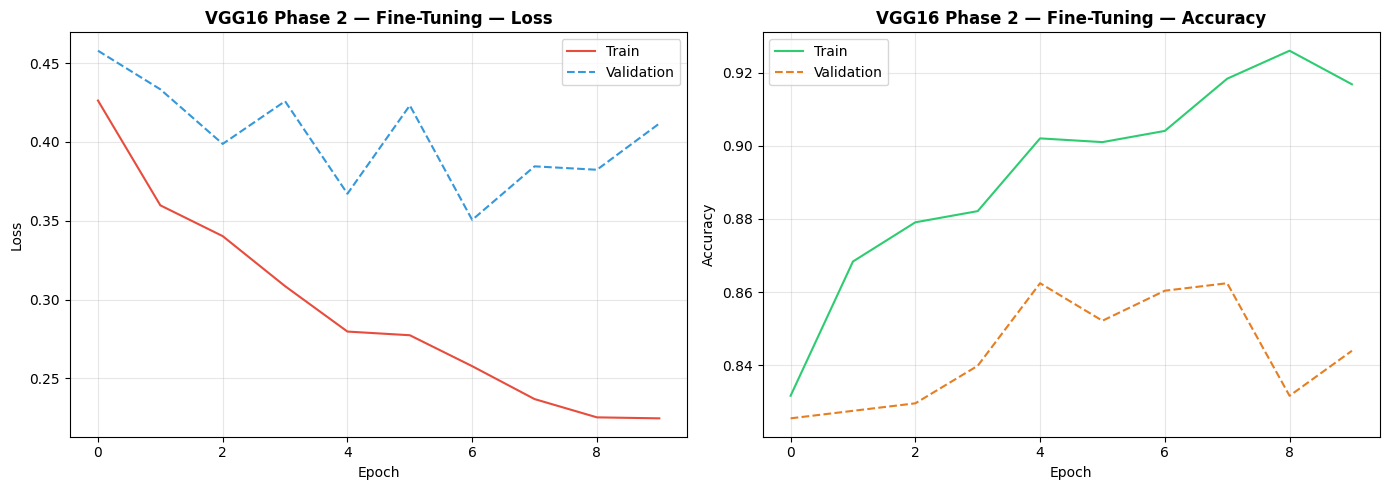

In [21]:
# Phase 2: unfreeze the last 4 VGG16 layers so they can adapt to our MRI images
# we use a very low learning rate (1e-5) to avoid destroying the ImageNet weights
base_model.trainable = True
for layer in base_model.layers[:-4]:
    layer.trainable = False

print(f"Layers now trainable: {sum(1 for l in base_model.layers if l.trainable)}")

tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start = time.time()
history_tl_p2 = tl_model.fit(
    train_gen_tl, validation_data=val_gen_tl,
    epochs=10, callbacks=callbacks_tl, verbose=1,
)
tl_p2_time = time.time() - start
print(f"Phase 2 done in {tl_p2_time:.1f}s")
plot_history(history_tl_p2, 'VGG16 Phase 2 — Fine-Tuning', 'tl_phase2_curves.png')


VGG16 Transfer Learning — Test Results
Accuracy: 0.9002  (90.02%)

Classification Report (precision, recall, F1 per class):
              precision    recall  f1-score   support

      Glioma       0.94      0.87      0.91       181
  Meningioma       0.82      0.90      0.86       183
      Normal       0.94      0.88      0.91        88
   Pituitary       0.94      0.94      0.94       169

    accuracy                           0.90       621
   macro avg       0.91      0.90      0.90       621
weighted avg       0.90      0.90      0.90       621



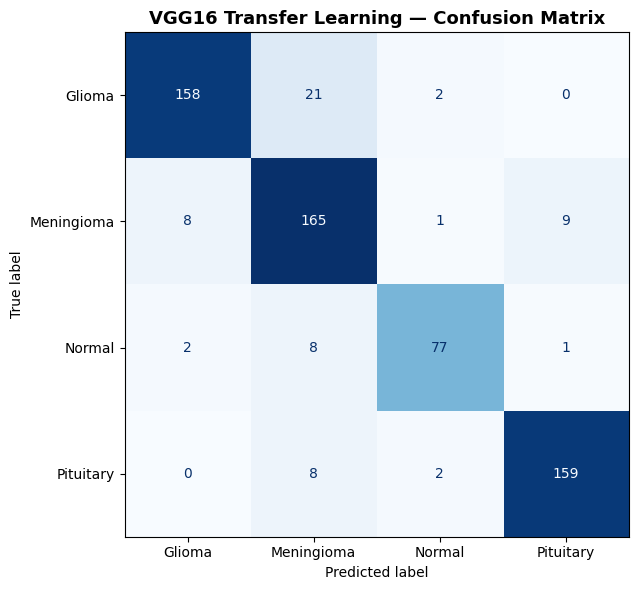

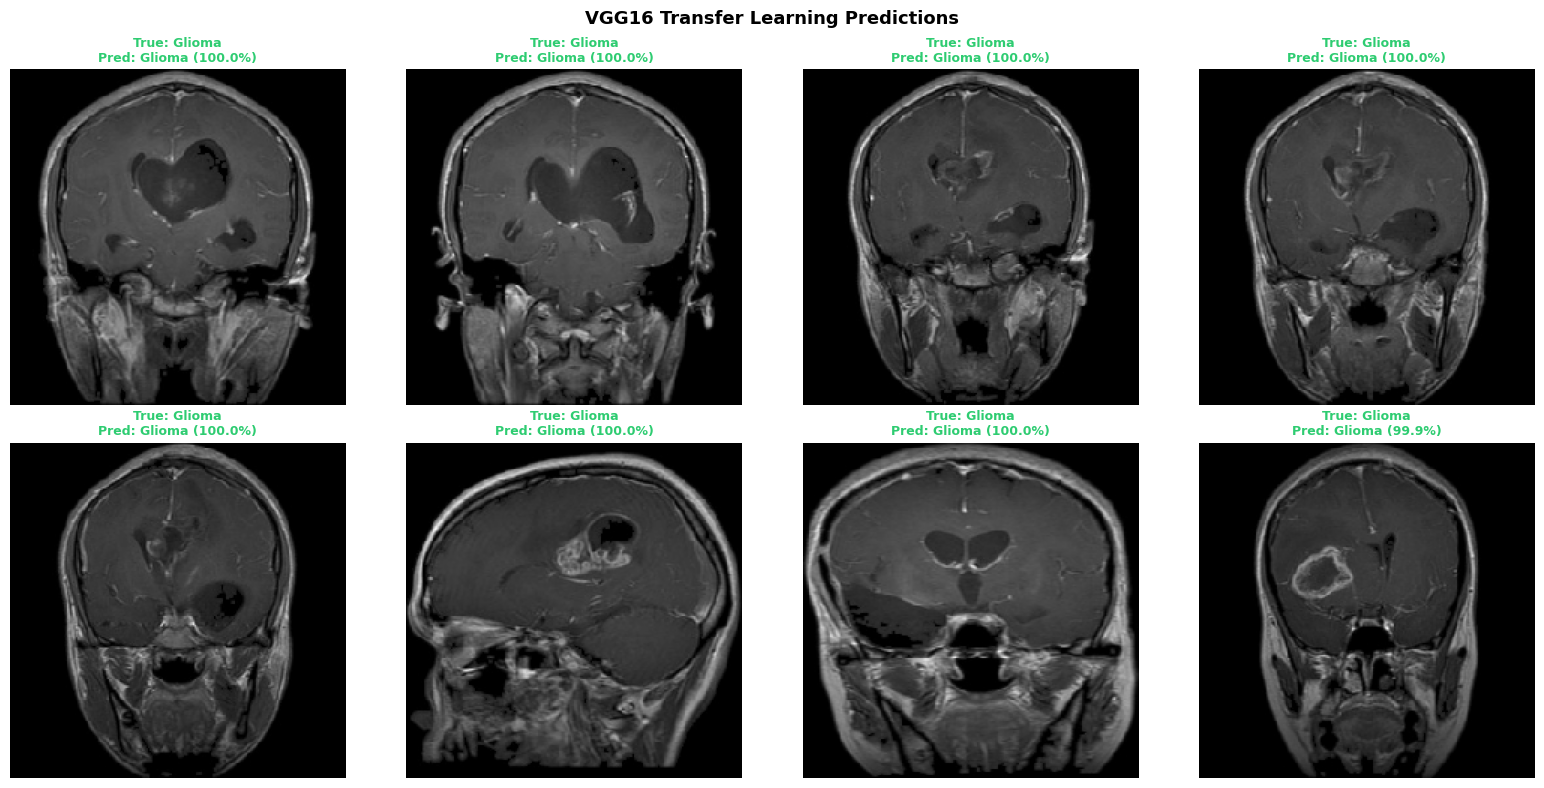


FINAL RESULTS — ALL MODELS
  Baseline CNN                 82.29%
  Deeper CNN (Adam)            66.02%
  Deeper CNN (SGD)             38.65%
  VGG16 Transfer Learn.        90.02%


In [22]:
tl_acc, tl_preds, _ = evaluate_model(tl_model, test_gen_tl, "VGG16 Transfer Learning")
show_predictions(tl_model, test_gen_tl, title="VGG16 Transfer Learning Predictions")

# print a clean final summary of all models
print("\nFINAL RESULTS — ALL MODELS")
print("=" * 50)
for name, acc in [
    ("Baseline CNN",          baseline_acc),
    ("Deeper CNN (Adam)",     deeper_adam_acc),
    ("Deeper CNN (SGD)",      deeper_sgd_acc),
    ("VGG16 Transfer Learn.", tl_acc),
]:
    print(f"  {name:<28} {acc*100:.2f}%")
print("=" * 50)

In [23]:
# save everything so the report script can reference results without re-running training
baseline_model.save('baseline_cnn.h5')
deeper_model_adam.save('deeper_cnn_adam.h5')
tl_model.save('vgg16_transfer_learning.h5')
print("All models saved.")

All models saved.
